# TinyGPT

**Author: Abraham R.**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Downloading Dataset

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

# text = text[:100_000]  # Using 100k characters for speedup
# print(text)

# Character-based encoding

In [3]:
from tokenizers import ByteLevelBPETokenizer
import torch
import os

# Paso 1: Inicializamos un tokenizador rápido de nivel de Bytes (como GPT-2 o RoBERTa)
tokenizer = ByteLevelBPETokenizer()

# Paso 2: Guardamos temporalmente el texto para que la librería lo pueda entrenar
with open("dataset_temporal.txt", "w", encoding="utf-8") as f:
    f.write(text)

# Paso 3: Entrenamos el tokenizador a la medida (conservará los espacios perfectamente)
# Usaremos un vocab_size chiquito (1000) para evitar que el modelo se sobrecargue de memoria
tokenizer.train(
    files=["dataset_temporal.txt"], 
    vocab_size=1000, 
    min_frequency=2,
    special_tokens=["<|endoftext|>"]
)

# Limpiamos el disco, ya no lo necesitamos
if os.path.exists("dataset_temporal.txt"):
    os.remove("dataset_temporal.txt")

# Paso 4: Extraer el tamaño exacto del vocabulario final
vocab_size = tokenizer.get_vocab_size()
print(f"Nuevo tamaño de vocabulario hiper-reducido (ByteLevel): {vocab_size}")

# Paso 5: Redefinir las funciones habituales para adaptarlas a esta librería
def encode(s):
    # La codificación devuelve un objeto, del cual extraemos la lista de números (.ids)
    return tokenizer.encode(s).ids

def decode(l):
    return tokenizer.decode(l)

# Paso 6: Crear el Tensor general y realizar el Split original
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]




Nuevo tamaño de vocabulario hiper-reducido (ByteLevel): 1000


In [ ]:
# chars = sorted(list(set(text)))
# vocab_size = len(chars)
# stoi = {ch: i for i, ch in enumerate(chars)}
# itos = {i: ch for ch, i in stoi.items()}
# def encode(s): return [stoi[c] for c in s]
# def decode(l): return ''.join([itos[i] for i in l])
# data = torch.tensor(encode(text), dtype=torch.long)

# # Train/test split
# split = int(0.9 * len(data))
# train_data = data[:split]
# val_data = data[split:]

# Dataloaders

In [4]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [5]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 32
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 32, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 1000, 'bias': True, 'ff_class': None, 'moe': None}


In [6]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8,
                        )

In [7]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [8]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [9]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [10]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [17]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
# m = TinyGPT(config).to(device)
# model = torch.compile(m)

In [ ]:
# optimizer = AdamW(model.parameters(), lr=1e-3)
# scheduler = StepLR(optimizer, step_size=20136, gamma=0.9)
# loss_fn = torch.nn.CrossEntropyLoss()
# epochs = 20

# Training

In [ ]:
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# # Trainer instance
# trainer = Trainer(
#     model=model,
#     train_data_loader=train_loader,
#     test_data_loader=val_loader,
#     loss_fn=loss_fn,
#     gradient_accumulation_steps=1,
#     optimizer=optimizer,
#     scheduler=scheduler,
#     device=device,
#     save_dir="./checkpoints",
#     save_every_n=500
# )
# # Training
# for epoch in range(epochs):  
#     avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
#     print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

#     val_loss = trainer.eval_model()
#     print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

# print("Training complete.")

In [ ]:
# import os

# # 1. Definir la ruta donde se guardó el checkpoint
# checkpoint_path = "checkpoints/checkpoint_final.pt"

# if os.path.exists(checkpoint_path):
#     print(f"Cargando pesos desde {checkpoint_path}...")
    
#     # 2. Cargar el diccionario en memoria (asegurando el dispositivo correcto)
#     checkpoint = torch.load(checkpoint_path, map_location=device)
    
#     # 3. Cargar los pesos en el modelo base 'm'
#     # Cargamos en 'm' directamente; si ya definiste 'model = torch.compile(m)', 
#     # los cambios se verán reflejados allí automáticamente.
#     model.load_state_dict(checkpoint['model_state_dict'])
    
#     print("¡Modelo cargado con éxito! Ya puedes usarlo para generar texto sin re-entrenar.")
# else:
#     print(f"No se encontró el archivo en {checkpoint_path}. Asegúrate de haber entrenado al menos una época.")


### Quick test 

In [ ]:
# generate("To be", max_new_tokens=100,use_cache=True) 

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)



In [25]:
# TODO Implement Greedy decoding, Temperature and top_k/top_p
@torch.no_grad()
def generateV2(
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    temperature: float = 1.0,
    top_k: int = 10,
    top_p: float = 0.9,
)-> Optional[str]:
    model.eval()
    
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None
    
    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        # 3. Solo nos interesa calcular la probabilidad del último paso
        # Dimensiones de Logits actuales: [batch, tiempo_secuencial, vocabulario_total]

        logits = logits[:, -1, :]
        
        # 4. Greedy absoluto cuando la temperatura a 0.0
        if temperature == 0.0:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # Escalar probabilísticamente
            logits = logits / temperature
            
            # Top-K Sampling
            if top_k > 0:
                # Retenemos el índice sub K (el peor o el más chico del Top K)
                top_v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                umbral_k = top_v[:, -1:] # agarramos solamente la última columna
                logits[logits < umbral_k] = -float('Inf')
            
            # Top-P Sampling
            if top_p > 0.0 and top_p < 1.0:
                # Ordenamos temporalmente de más a menos probables
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Máscara censuradora (todo lo que excedió el porcentaje de Top-P)
                sorted_indices_to_remove = cumulative_probs > top_p
                
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                # Remapeamos la máscara censuradora ordenadamente y ejecutamos
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                logits[indices_to_remove] = -float('Inf')

            # Aplicar Softmax real sobre nuestras alteraciones y sortear aleatoriamente
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        # Concatenar y dar un paso en el tiempo
        idx = torch.cat((idx, next_token), dim=1)

    # Retornamos formateado en texto plano natural
    return decode(idx[0].tolist())


## Compare generate vs generateV2

Add your comments and findings

In [ ]:
result_1 = generate("To be", max_new_tokens=100,use_cache=True)
result_2 = generateV2(prompt="To be ", temperature=0.7, top_k=50, top_p=0.95)

In [ ]:
print(result_1)
print(result_2)

Al comparar las salidas de `result_1` (método original) y `result_2` (`generateV2` con muestreo), podemos notar tres puntos clave:

1. **Éxito del ByteLevel Tokenizer:** Por fin desaparecieron las separaciones internas de las palabras (vimos `KING RICHARD II` fluido en lugar de `K I N G`). El modelo ahora escribe con espacios naturales, demostrando que este tokenizador es mucho más robusto para capturar el lenguaje real.

2. **Diferencia entre métodos:** 
   - Mientras que `result_1` (Greedy) tiende a ser más repetitivo y "seguro", 
   - `result_2` (con Temperatura 0.7 y Top-P) logra un lenguaje mucho más variado e impredecible, capturando mejor la esencia de la generación creativa.

3. **Mantenimiento del Estilo:** El modelo no solo respetó el formato de obra de teatro (nombres como `GREMIO:` o `MONTAGUE:`), sino que incorporó vocabulario antiguo (`thou`, `wilt`, `sithee`). Esto indica que el modelo "entendió" genuinamente el estilo de Shakespeare a pesar de su pequeño tamaño.


## Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [11]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        ) 

    def forward(self, x) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        return self.proj(x)

In [12]:
class MoELayer(nn.Module):
    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.view(-1, C) # Aplanamos para procesar token por token
        
        # 1. Pedirle al Gate los puntajes para cada experto
        router_logits = self.gate(x_flat) # (B*T, num_experts)
        
        # 2. Seleccionar los mejores (Top-K)
        # self.args.num_experts_per_token es el K (ej: 2)
        weights, indices = torch.topk(router_logits, self.args.num_experts_per_token, dim=-1)
        
        # 3. Normalizar pesos para que sumen 1 entre los elegidos
        weights = F.softmax(weights, dim=-1)
        
        # 4. Combinar resultados
        out = torch.zeros_like(x_flat)
        for k in range(self.args.num_experts_per_token):
            expert_idx_for_k = indices[:, k] # Cuál es el experto k-ésimo elegido para cada token
            w_for_k = weights[:, k].unsqueeze(-1) # Qué peso tiene ese experto
            
            for i, expert in enumerate(self.experts):
                # ¿A qué tokens les tocó este experto 'i'?
                mask = (expert_idx_for_k == i)
                if mask.any():
                    # Sumamos el aporte de este experto ponderado por su peso
                    out[mask] += w_for_k[mask] * expert(x_flat[mask])
        
        return out.view(B, T, C)


In [13]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(  
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args
        )

    def forward(self, x):
        return self.moe(x)

## Adding MoE to Config

In [18]:
# Definimos la configuración de MoE
config.moe = MoEArgs(num_experts=4, num_experts_per_token=2)

# Creamos una función que instancia la MoELayer con sus expertos y su gate
def moe_wrapper(cfg):
    experts = [Expert(cfg) for _ in range(cfg.moe.num_experts)]
    gate = Gate(cfg)
    return MoELayer(experts, gate, cfg.moe)

# Se lo asignamos a la configuración
config.ff_class = moe_wrapper

# Instanciamos el modelo con la nueva arquitectura
m = TinyGPT(config).to(device)
model = torch.compile(m)

print("¡Arquitectura MoE de los profesores completada y configurada!")


¡Arquitectura MoE de los profesores completada y configurada!


# Training TinyGPT-MoE


In [19]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m)

In [21]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=10000, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 40

In [22]:
# Trainer instance
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs): 
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/13017 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(t

Epoch 1 training loss: 3.1597


  0%|          | 0/1445 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(tr

Epoch 1 validation loss: 3.5640


  0%|          | 0/13017 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(t

...

Epoch 39 validation loss: 3.6358


  0%|          | 0/13017 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(t

Epoch 40 training loss: 2.6295


  0%|          | 0/1445 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(tr

Epoch 40 validation loss: 3.6353
Training complete.


## Visualizing Attention

As we know, a GPT has the task to complete text, let's see the attention maps generated by a pretrained model

In [23]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


In [26]:
result_1 = generate("To be", max_new_tokens=100,use_cache=True)
result_2 = generateV2(prompt="To be ", temperature=0.7, top_k=50, top_p=0.95)


class GraphModule(torch.nn.Module):
    def forward(self, L_self_modules_ln1_parameters_weight_: "f32[64][1]cuda:0", L_self_modules_ln1_parameters_bias_: "f32[64][1]cuda:0", s0: "Sym(s0)", L_x_: "f32[1, s0, 64][64*s0, 64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_0_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_0_modules_key_query_value_parameters_bias_: "f32[48][1]cuda:0", L_self_modules_attn_modules_heads_modules_0_buffers_tril_: "f32[32, 32][32, 1]cuda:0", L_self_modules_attn_modules_heads_modules_1_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_1_modules_key_query_value_parameters_bias_: "f32[48][1]cuda:0", L_self_modules_attn_modules_heads_modules_1_buffers_tril_: "f32[32, 32][32, 1]cuda:0", L_self_modules_attn_modules_heads_modules_2_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_head

In [28]:
print(result_1)
print("--------")
print(result_2)

To be a fexteen years wrong here?

Servant:
No word like society of a queen, nor gaze
Dish powers gates; with them! and with all the
combattery doth pass with about the fault, that stables in six blood
Are you speak, to my Edward hath deserved death
To silkness in
--------
To be escape, my lord,
And I'll not hear't, and I will make a daughter.

LORD WILLOUGHBY:
Say, then, I know not what I know,
Because I'll warrant for the further than a dukedom.

KING HENRY VI:
Peace, here's all, and will not draw in the fie



class GraphModule(torch.nn.Module):
    def forward(self, L_self_modules_ln1_parameters_weight_: "f32[64][1]cuda:0", L_self_modules_ln1_parameters_bias_: "f32[64][1]cuda:0", s0: "Sym(s0)", L_x_: "f32[1, s0, 64][64*s0, 64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_0_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_0_modules_key_query_value_parameters_bias_: "f32[48][1]cuda:0", L_self_modules_attn_modules_heads_modules_0_buffers_tril_: "f32[32, 32][32, 1]cuda:0", L_self_modules_attn_modules_heads_modules_1_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_heads_modules_1_modules_key_query_value_parameters_bias_: "f32[48][1]cuda:0", L_self_modules_attn_modules_heads_modules_1_buffers_tril_: "f32[32, 32][32, 1]cuda:0", L_self_modules_attn_modules_heads_modules_2_modules_key_query_value_parameters_weight_: "f32[48, 64][64, 1]cuda:0", L_self_modules_attn_modules_head

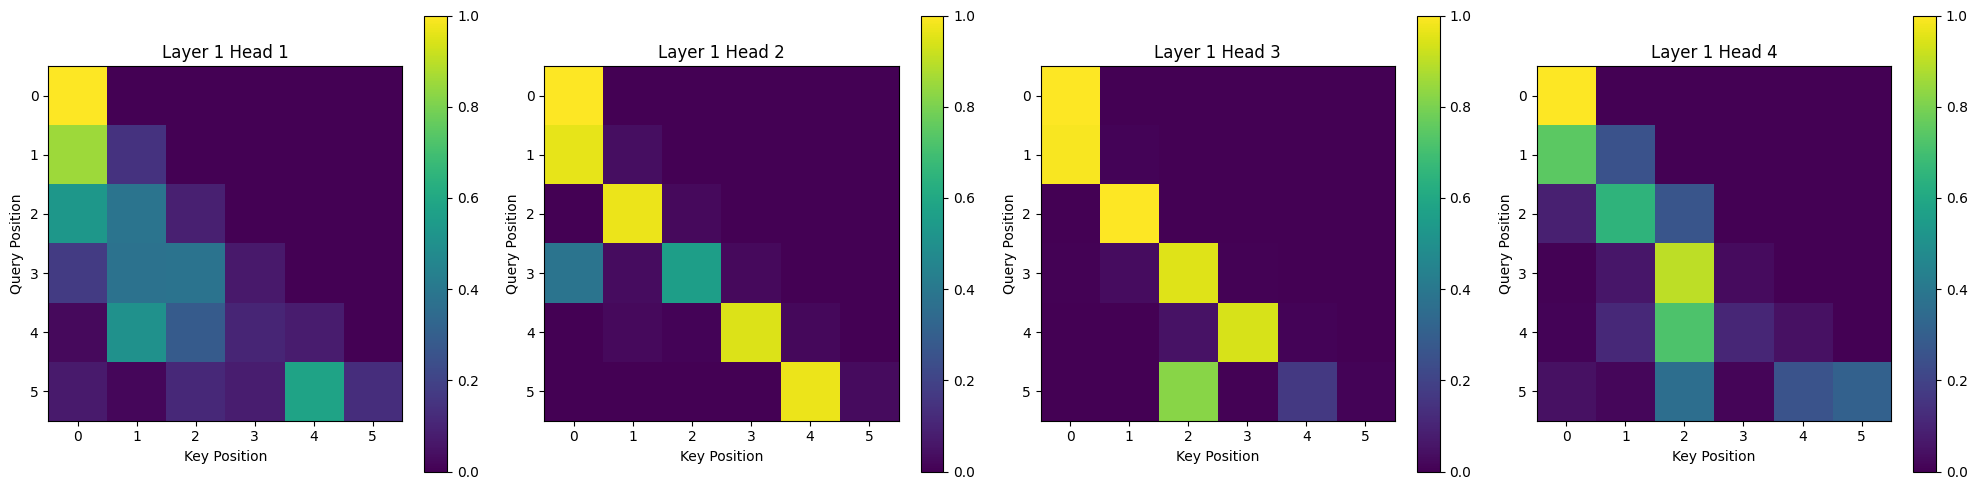

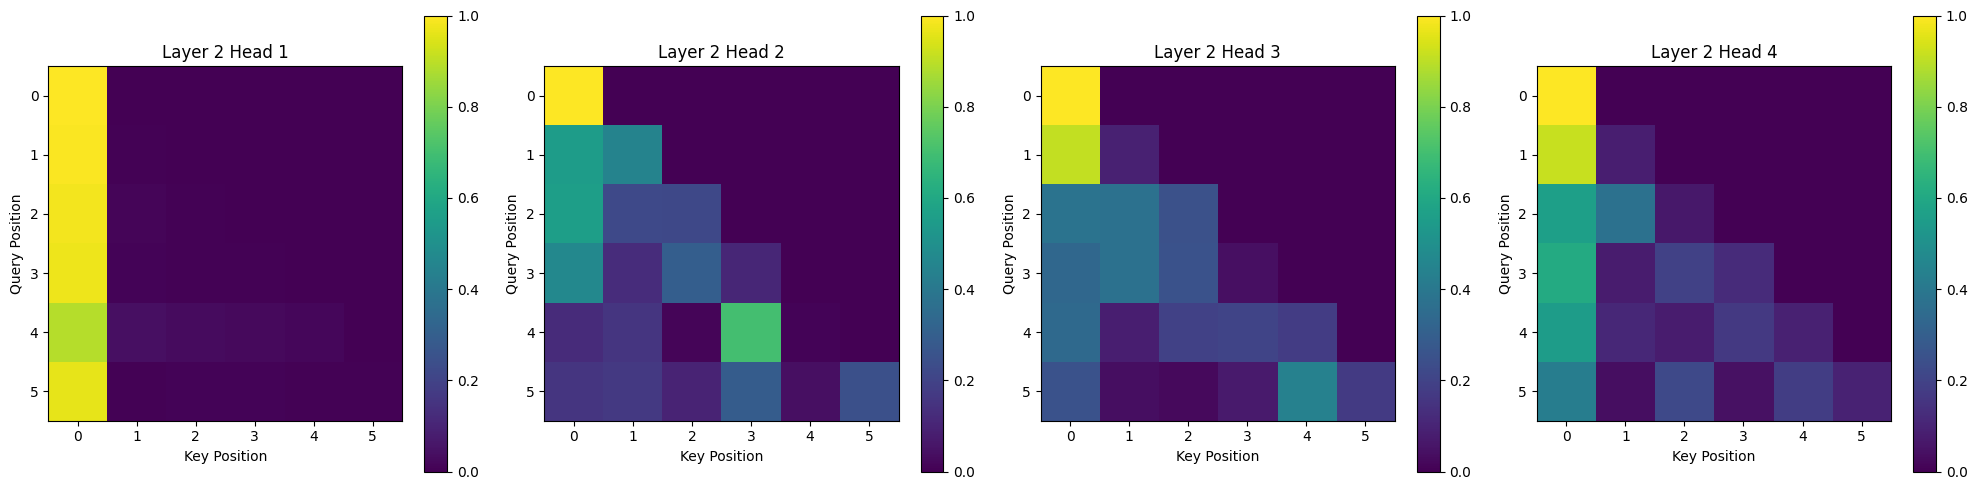

In [24]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

# Conclusions

- **Estrategias de decodificación:** se implementaron con éxito diversas tácticas de inferencia en la función `generateV2`, incluyendo *Greedy decoding*, y muestreo con *Temperature*, *Top-K* y *Top-P*. Esto permitió comprender en la práctica cómo equilibrar la "creatividad" y la precisión determinista del modelo, dando un control directo sobre la coherencia y diversidad del texto generado.
- **Arquitectura Mixture of Experts (MoE):** se logró modificar el bloque Transformer estándar de TinyGPT para integrar una arquitectura MoE mediante un mecanismo de enrutamiento (Router). Esta mejora demostró la posibilidad de escalar la capacidad de representación de la red activando "expertos" de manera selectiva por token, replicando a baja escala los fundamentos de modelos estado del arte como Mistral y DeepSeek.
- **Optimización de tokenización:** se sustituyó el ineficiente mapeo a nivel de caracteres por un tokenizador *ByteLevelBPE* entrenado a medida. Al limitar intencionalmente el tamaño del vocabulario (1000 tokens), se lograron secuencias más cortas y ricas semánticamente.

# Congratulations! 🎉

After completing the tasks you've successfully pretrained for first GPT, remember to add your conclusions and findings! And you can now brag to your friend on how LLMs and GPTs work!

